# Horizon chromaticity: eigenmode / PCA analysis

Compares foreground chromaticity of the three horizon cases
(`nohorizon`, `quarry`, `eigsep`) via SVD of the simulated spectra, and
tests how much 21-cm signal survives projecting out the dominant
beam-weighted foreground modes.

The analysis is done on the **ground-loss-corrected sky temperature**

$$T_{\rm sky} = \frac{T_{\rm sys} - T_{\rm rcvr} - f_{\rm gnd} T_{\rm gnd}}{1 - f_{\rm gnd}},$$

i.e. the beam-weighted average sky temperature over the visible sky
(`eigsim.correct_ground_loss`). The raw `t_sys` singular values are
kept alongside for comparison.

**Inputs** (run `make_horizons.py`, `run_sims.py --case <c>` for all
three cases, and `compute_fgnd.py` first):

- `../output/horizons.npz` — masks + quarry cut metadata
- `../output/chromaticity_<case>.npz` — noiseless `t_sys`
  `(1296 orientations, 1436 times, 201 freqs)`
- `../output/fgnd_<case>.npz` — ground fractions
  `(1296 orientations, 201 freqs)`
- 21-cm signal models (K, MHz after conversion) from
  `~/Documents/research/eigsep/mock_analysis/notebooks/spatial_filter/models_21cm.npz`

Sections: sanity waterfalls → horizon profiles & azimuth slice → SVD
singular values, raw vs corrected (Fig. 1) → 21-cm models → foreground
filtering vs signal survival (Fig. 2).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm

OUTPUT_DIR = Path("..") / "output"
CASES = ["nohorizon", "quarry", "eigsep"]
COLORS = {"nohorizon": "C0", "quarry": "C1", "eigsep": "C2"}

# 21-cm model set (file stores freqs in GHz, models in mK)
T21_FILE = (
    Path.home()
    / "Documents/research/eigsep/mock_analysis/notebooks"
    / "spatial_filter/models_21cm.npz"
)

# orientations for the sanity waterfalls: zenith, horizon-pointing, upside-down
WATERFALL_ORI = [(0.0, 0.0), (90.0, 0.0), (180.0, 0.0)]
# elevation ring for the azimuth slice (90 = beam pointing at the horizon)
AZ_SLICE_ELEV = 90.0

## Horizon profiles

Altitude of the horizon vs azimuth for each case, plus the blocked-sky
summary saved by `make_horizons.py`. The quarry cut is the constant-
altitude horizon with the same blocked solid angle as the realistic
eigsep horizon.

In [2]:
hz = np.load(OUTPUT_DIR / "horizons.npz")
ntheta, nphi = hz["eigsep"].shape
theta_deg = np.degrees(np.linspace(0, np.pi, ntheta))
phi_deg = np.degrees(np.linspace(0, 2 * np.pi, nphi, endpoint=False))


def horizon_altitude_profile(mask):
    """Horizon altitude (deg) vs azimuth; -90 where nothing is blocked."""
    blocked = ~mask  # (ntheta, nphi)
    alt = np.full(nphi, -90.0)
    for j in range(nphi):
        rows = np.nonzero(blocked[:, j])[0]
        if rows.size:
            alt[j] = 90.0 - theta_deg[rows.min()]
    return alt


profiles = {c: horizon_altitude_profile(hz[c]) for c in CASES}

print(
    f"quarry cut: theta_c = {float(hz['theta_c_deg']):.2f} deg "
    f"(horizon altitude {90 - float(hz['theta_c_deg']):.2f} deg)"
)
for c in CASES:
    om = float(hz[f"omega_blocked_{c}"])
    print(f"  {c:10s} blocked {om:7.4f} sr = {om / (4 * np.pi):5.1%} of sphere")

quarry cut: theta_c = 71.16 deg (horizon altitude 18.84 deg)
  nohorizon  blocked  0.0000 sr =  0.0% of sphere
  quarry     blocked  8.2394 sr = 65.6% of sphere
  eigsep     blocked  8.2214 sr = 65.4% of sphere


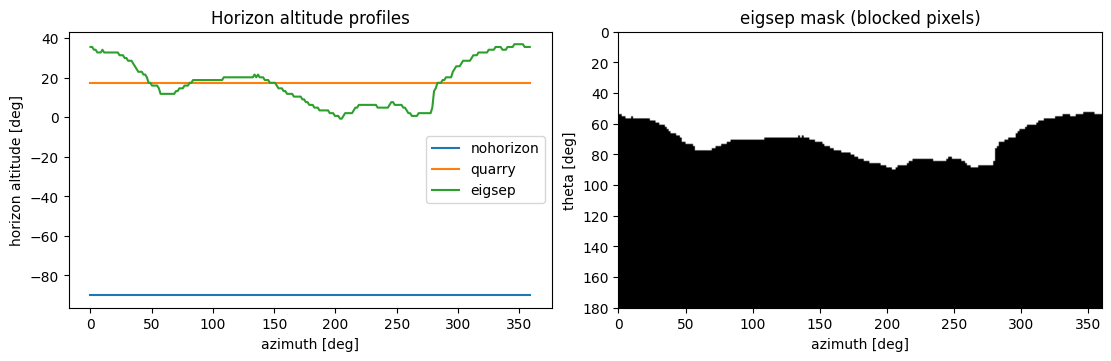

In [3]:
fig, axs = plt.subplots(1, 2, figsize=(11, 3.5), constrained_layout=True)

for c in CASES:
    axs[0].plot(phi_deg, profiles[c], color=COLORS[c], label=c)
axs[0].set_xlabel("azimuth [deg]")
axs[0].set_ylabel("horizon altitude [deg]")
axs[0].set_title("Horizon altitude profiles")
axs[0].legend()

axs[1].imshow(
    np.where(hz["eigsep"], np.nan, 1.0),
    extent=[0, 360, 180, 0],
    aspect="auto",
    cmap="copper",
)
axs[1].set_xlabel("azimuth [deg]")
axs[1].set_ylabel("theta [deg]")
axs[1].set_title("eigsep mask (blocked pixels)")
plt.show()

## Extraction pass over the three simulation files

Each `chromaticity_<case>.npz` holds a ~3 GB `t_sys` array, so we load
one case at a time and keep only what we need:

- the three waterfall orientations (raw `t_sys`, for sim sanity),
- the frequency-frequency Gram matrix `G = X.T @ X` of
  `X = t_sys.reshape(-1, n_freqs)` **before and after** ground-loss
  correction (eigenvectors of `G` are the right-singular vectors of
  `X`; eigenvalues are the squared singular values),
- the time-averaged azimuth ring at `AZ_SLICE_ELEV` (corrected).

The correction `t_sky = (t_sys - t_rcvr - fgnd*Tgnd) / (1 - fgnd)` is
applied in place (the array is ~3 GB); `fgnd` comes from
`fgnd_<case>.npz` and broadcasts over the time axis. The horizon-mask
SHA of the two files must match. No mean subtraction — we want the
dominant raw foreground shapes, including the overall spectrum.

In [4]:
meta = None
extract = {}

for c in CASES:
    d = np.load(OUTPUT_DIR / f"chromaticity_{c}.npz")
    fg = np.load(OUTPUT_DIR / f"fgnd_{c}.npz")
    assert str(d["mask_sha"]) == str(fg["mask_sha"]), f"{c}: mask SHA mismatch"
    t_sys = d["t_sys"]  # (n_ori, n_times, n_freqs)
    elev, az = d["elevations"], d["azimuths"]
    fgnd = fg["fgnd"]  # (n_ori, n_freqs)
    t_rcvr = float(d["t_receiver"])
    t_gnd = float(d["t_ground"])
    if meta is None:
        meta = dict(
            freqs=d["freqs_mhz"], times_jd=d["times_jd"], elev=elev, az=az
        )
    n_ori, n_times, n_freqs = t_sys.shape

    wf = {}
    for e, a in WATERFALL_ORI:
        (idx,) = np.nonzero((elev == e) & (az == a))
        wf[(e, a)] = t_sys[idx[0]].copy()  # raw t_sys (n_times, n_freqs)

    X = t_sys.reshape(-1, n_freqs)  # view into t_sys
    G_raw = X.T @ X

    # ground-loss correction, in place (X is a view, so it updates too)
    t_sys -= t_rcvr + fgnd[:, None, :] * t_gnd
    t_sys /= 1.0 - fgnd[:, None, :]
    G_sky = X.T @ X

    (ring,) = np.nonzero(elev == AZ_SLICE_ELEV)
    az_slice = t_sys[ring].mean(axis=1)  # corrected, (n_az, n_freqs)

    extract[c] = dict(
        wf=wf,
        az_ring=az[ring],
        az_slice=az_slice,
        G=G_sky,
        G_raw=G_raw,
        fgnd=fgnd,
        n_samples=X.shape[0],
    )
    del t_sys, X, d
    print(f"{c}: extracted ({n_ori} ori x {n_times} times x {n_freqs} freqs)")

freqs = meta["freqs"]
times_hr = (meta["times_jd"] - meta["times_jd"][0]) * 24.0

nohorizon: extracted (1296 ori x 1436 times x 201 freqs)


quarry: extracted (1296 ori x 1436 times x 201 freqs)


eigsep: extracted (1296 ori x 1436 times x 201 freqs)


## Sanity waterfalls

Raw (uncorrected) system temperature vs time and frequency, per case
(rows) and orientation (columns). These should look like normal
foreground waterfalls: smooth power-law spectra, galaxy transiting in
time; upside-down (el=180) should be ground-dominated (~300 K, flat)
for the two cases with a horizon and sky-dominated for `nohorizon`.

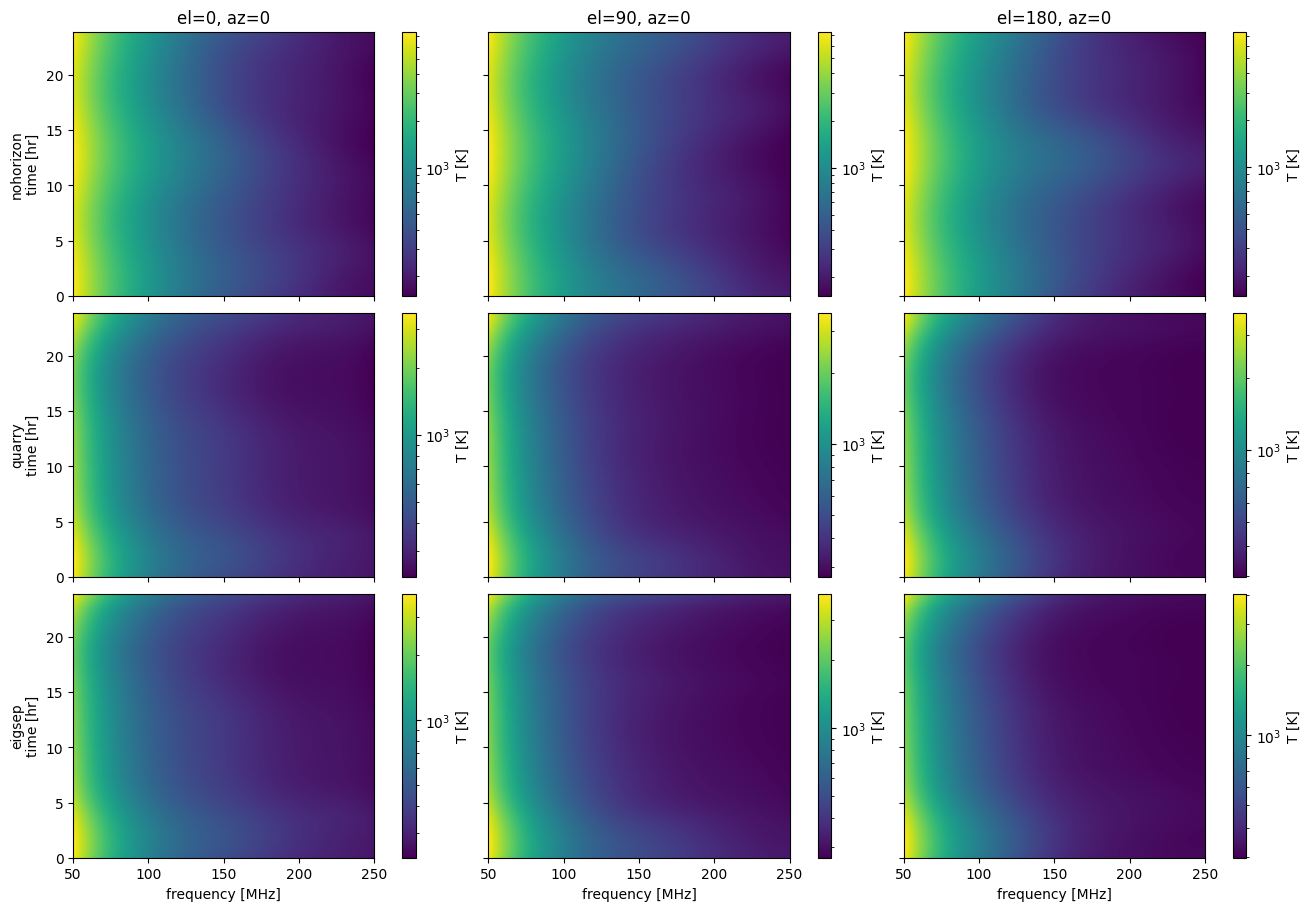

In [5]:
fig, axs = plt.subplots(
    3,
    len(WATERFALL_ORI),
    figsize=(13, 9),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)
for i, c in enumerate(CASES):
    for j, ori in enumerate(WATERFALL_ORI):
        ax = axs[i, j]
        T = extract[c]["wf"][ori]  # (n_times, n_freqs)
        im = ax.imshow(
            T,
            aspect="auto",
            origin="lower",
            extent=[freqs[0], freqs[-1], times_hr[0], times_hr[-1]],
            norm=LogNorm(),
        )
        fig.colorbar(im, ax=ax, label="T [K]")
        if i == 0:
            ax.set_title(f"el={ori[0]:.0f}, az={ori[1]:.0f}")
        if j == 0:
            ax.set_ylabel(f"{c}\ntime [hr]")
        if i == len(CASES) - 1:
            ax.set_xlabel("frequency [MHz]")
plt.show()

## Azimuth slice

Time-averaged **ground-loss-corrected** sky temperature vs azimuth with
the beam pointed at the horizon (el=90), at a few frequencies. With the
ground pickup removed and the visible-sky normalization applied, all
remaining structure is sky seen through the open part of the beam: the
azimuthally-symmetric cases should be smooth in azimuth (residual
structure comes from the sky and the non-symmetric beam); the eigsep
case picks up the azimuthal structure of the real horizon.

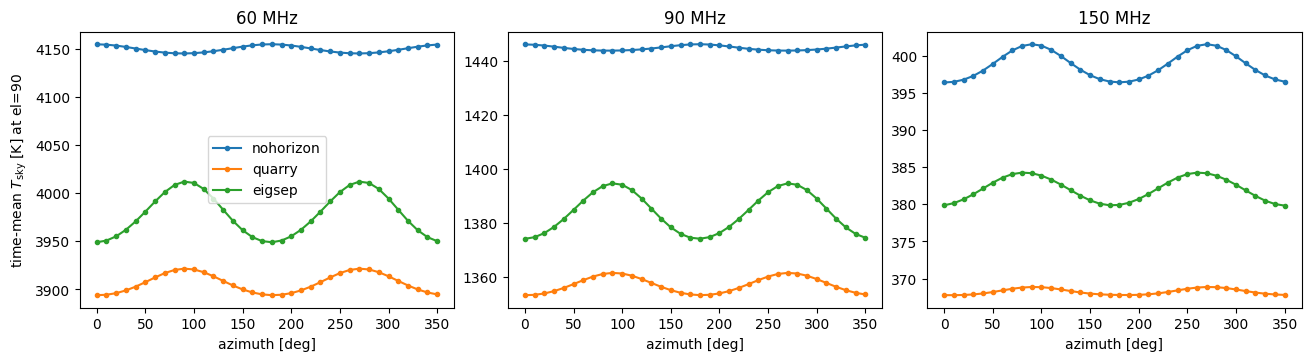

In [6]:
SLICE_FREQS = [60.0, 90.0, 150.0]

fig, axs = plt.subplots(
    1, len(SLICE_FREQS), figsize=(13, 3.5), sharex=True, constrained_layout=True
)
for ax, fmhz in zip(axs, SLICE_FREQS):
    k = int(np.argmin(np.abs(freqs - fmhz)))
    for c in CASES:
        order = np.argsort(extract[c]["az_ring"])
        ax.plot(
            extract[c]["az_ring"][order],
            extract[c]["az_slice"][order, k],
            color=COLORS[c],
            marker=".",
            label=c,
        )
    ax.set_title(f"{freqs[k]:.0f} MHz")
    ax.set_xlabel("azimuth [deg]")
axs[0].set_ylabel(f"time-mean $T_{{\\rm sky}}$ [K] at el={AZ_SLICE_ELEV:.0f}")
axs[0].legend()
plt.show()

## SVD of the full datasets

`X = t_sky.reshape(n_ori * n_times, n_freqs)`; the frequency eigenmodes
and singular values come from the eigendecomposition of the Gram
matrices computed in the extraction pass — once for the raw `t_sys`
and once for the ground-loss-corrected `t_sky`. All downstream analysis
uses the corrected `svd`; `svd_raw` is kept to quantify what the
correction changes.

In [7]:
def gram_svd(G):
    """Singular values / right-singular vectors of X from G = X.T @ X."""
    evals, evecs = np.linalg.eigh(G)
    order = np.argsort(evals)[::-1]
    s = np.sqrt(np.clip(evals[order], 0.0, None))
    V = evecs[:, order]  # columns = frequency modes
    V *= np.sign(V.sum(axis=0, keepdims=True) + 1e-300)  # sign convention
    return dict(s=s, V=V)


svd = {c: gram_svd(extract[c]["G"]) for c in CASES}  # corrected t_sky
svd_raw = {c: gram_svd(extract[c]["G_raw"]) for c in CASES}

hdr = f"{'case':10s} {'s1/s2':>16s} {'s1/s10':>22s}"
print(hdr + "\n" + " " * 11 + f"{'raw':>7s} {'sky':>8s} {'raw':>11s} {'sky':>10s}")
for c in CASES:
    sr, ss = svd_raw[c]["s"], svd[c]["s"]
    print(
        f"{c:10s} {sr[0] / sr[1]:7.1f} {ss[0] / ss[1]:8.1f} "
        f"{sr[0] / sr[9]:11.2e} {ss[0] / ss[9]:10.2e}"
    )

case                  s1/s2                 s1/s10
               raw      sky         raw        sky
nohorizon     85.2     85.3    1.45e+05   1.34e+05
quarry        21.7     75.8    2.54e+04   2.50e+04
eigsep        19.7     69.6    2.54e+04   2.26e+04


### Does the ground-loss correction change the singular values?

Three effects are in play:

1. removing the constant receiver temperature and the (weakly
   chromatic) `fgnd*Tgnd` ground pickup mostly reshuffles power in the
   first one or two modes;
2. dividing by `1 - fgnd` rescales every spectrum by an orientation-
   and frequency-dependent factor — this can add or remove genuine
   chromatic structure;
3. for `nohorizon`, `fgnd = 0` identically, so the correction is just
   a 50 K receiver subtraction.

The plot compares the normalized singular value spectra before (dashed)
and after (solid) correction.

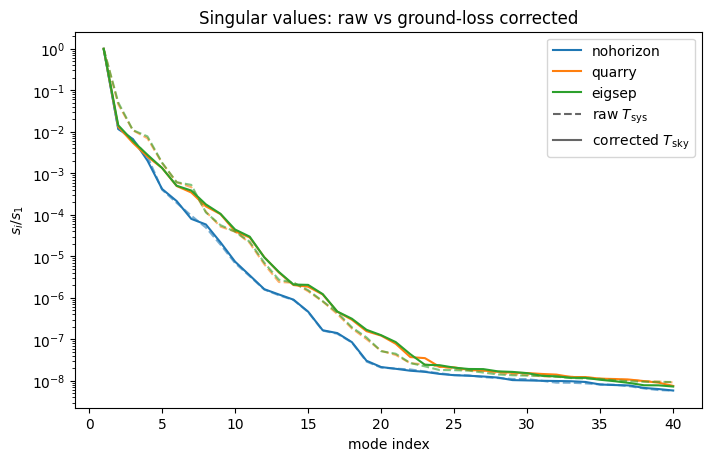

max |Δ(s_i/s_1)| / (s_i/s_1) over modes 2-10:
  nohorizon  20.49%
  quarry     99.97%
  eigsep     87.64%


In [8]:
N_CMP = 40

fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
for c in CASES:
    sr, ss = svd_raw[c]["s"], svd[c]["s"]
    ax.semilogy(
        np.arange(1, N_CMP + 1),
        sr[:N_CMP] / sr[0],
        color=COLORS[c],
        ls="--",
        alpha=0.6,
    )
    ax.semilogy(
        np.arange(1, N_CMP + 1), ss[:N_CMP] / ss[0], color=COLORS[c], label=c
    )
ax.plot([], [], color="0.4", ls="--", label=r"raw $T_{\rm sys}$")
ax.plot([], [], color="0.4", label=r"corrected $T_{\rm sky}$")
ax.set_xlabel("mode index")
ax.set_ylabel(r"$s_i / s_1$")
ax.set_title("Singular values: raw vs ground-loss corrected")
ax.legend()
plt.show()

# relative change in normalized singular values for the first 10 modes
print("max |Δ(s_i/s_1)| / (s_i/s_1) over modes 2-10:")
for c in CASES:
    sr, ss = svd_raw[c]["s"], svd[c]["s"]
    rel = np.abs(ss[1:10] / ss[0] - sr[1:10] / sr[0]) / (sr[1:10] / sr[0])
    print(f"  {c:10s} {rel.max():.2%}")

### Figure 1: singular value spectra

Ground-loss-corrected `t_sky`. Steeper fall-off = less chromatic =
fewer modes needed to describe the foregrounds. Right panel shows the
first three frequency eigenmodes per case.

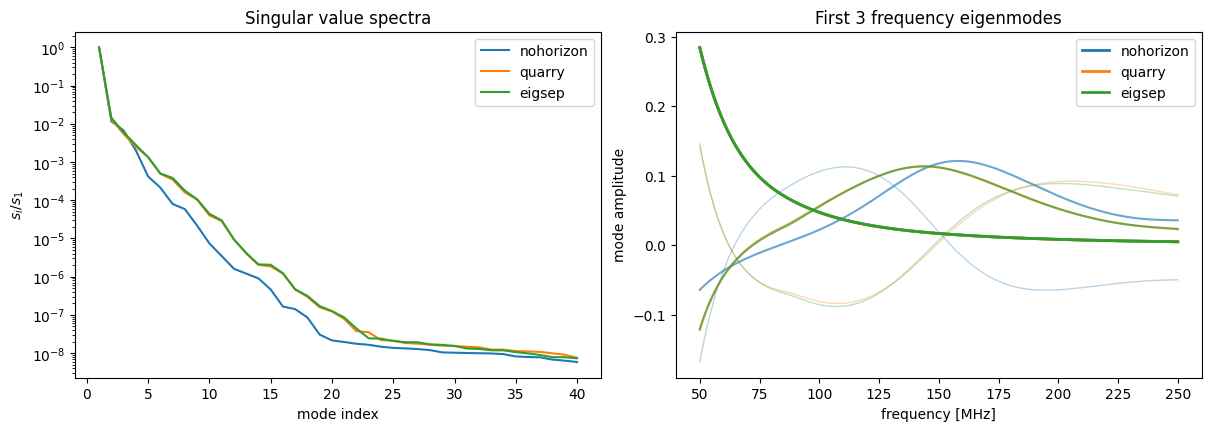

In [9]:
N_SHOW = 40

fig, axs = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)

for c in CASES:
    s = svd[c]["s"]
    axs[0].semilogy(
        np.arange(1, N_SHOW + 1), s[:N_SHOW] / s[0], color=COLORS[c], label=c
    )
axs[0].set_xlabel("mode index")
axs[0].set_ylabel(r"$s_i / s_1$")
axs[0].set_title("Singular value spectra")
axs[0].legend()

for c in CASES:
    V = svd[c]["V"]
    for m in range(3):
        axs[1].plot(
            freqs,
            V[:, m],
            color=COLORS[c],
            alpha=1.0 - 0.35 * m,
            lw=2.0 - 0.5 * m,
            label=c if m == 0 else None,
        )
axs[1].set_xlabel("frequency [MHz]")
axs[1].set_ylabel("mode amplitude")
axs[1].set_title("First 3 frequency eigenmodes")
axs[1].legend()
plt.show()

fig.savefig("fig1_singular_values.pdf", bbox_inches="tight")

## 21-cm signal models

The file stores frequencies in GHz and brightness temperatures in mK;
convert to MHz / K and interpolate onto the simulation frequency grid
(the model grid ends at 249 MHz; the last simulated channel at 250 MHz
takes the 249 MHz endpoint value, negligible where the signal is ~0).
Nominal model = median absorption-trough depth. We also build signal
eigenmodes from the model set itself.

In [10]:
t21_d = np.load(T21_FILE)
freqs21 = t21_d["freqs"] * 1e3  # GHz -> MHz
models21 = t21_d["models"] / 1e3  # mK -> K

assert 40 < freqs21[0] < 60 and 200 < freqs21[-1] < 260, "frequency units?"
assert -0.6 < models21.min() < -0.02, "temperature units?"
print(
    f"{models21.shape[0]} models, {freqs21[0]:.0f}-{freqs21[-1]:.0f} MHz, "
    f"trough depths {models21.min(axis=1).min() * 1e3:.0f} to "
    f"{models21.min(axis=1).max() * 1e3:.0f} mK"
)

# interpolate onto the simulation grid
t21 = np.array([np.interp(freqs, freqs21, m) for m in models21])  # (n_models, n_freqs) [K]

depth = t21.min(axis=1)
nominal_idx = int(np.argsort(depth)[len(depth) // 2])
t21_nom = t21[nominal_idx]

# signal eigenmodes from the model family
_, s21, Vt21 = np.linalg.svd(t21, full_matrices=False)

1135 models, 50-249 MHz, trough depths -256 to -3 mK


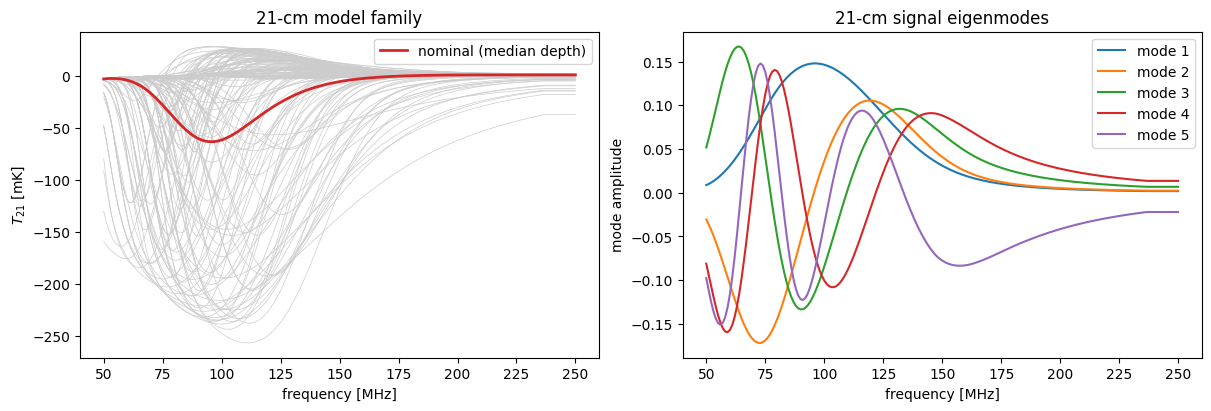

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

axs[0].plot(freqs, t21[:: max(1, len(t21) // 150)].T * 1e3, color="0.8", lw=0.5)
axs[0].plot(freqs, t21_nom * 1e3, color="C3", lw=2, label="nominal (median depth)")
axs[0].set_xlabel("frequency [MHz]")
axs[0].set_ylabel(r"$T_{21}$ [mK]")
axs[0].set_title("21-cm model family")
axs[0].legend()

for m in range(5):
    axs[1].plot(freqs, Vt21[m], label=f"mode {m + 1}")
axs[1].set_xlabel("frequency [MHz]")
axs[1].set_ylabel("mode amplitude")
axs[1].set_title("21-cm signal eigenmodes")
axs[1].legend()
plt.show()

### Figure 2: foreground filtering vs 21-cm signal survival

Project out the leading `N` foreground frequency modes of each horizon
case from (a) the data — residual foreground RMS follows from the
discarded singular values — and (b) the 21-cm models.

- **Left:** foreground residual RMS per sample-channel after removing
  `N` modes, `sqrt(sum_{i>N} s_i^2 / (n_samples * n_freqs))`.
- **Right:** fraction of the 21-cm signal norm surviving the same
  projection, for the nominal model (line) and the 16-84% range over
  the full model family (band).

The question: for a fixed foreground suppression (say residual below a
few mK), how much 21-cm signal does each horizon cost?

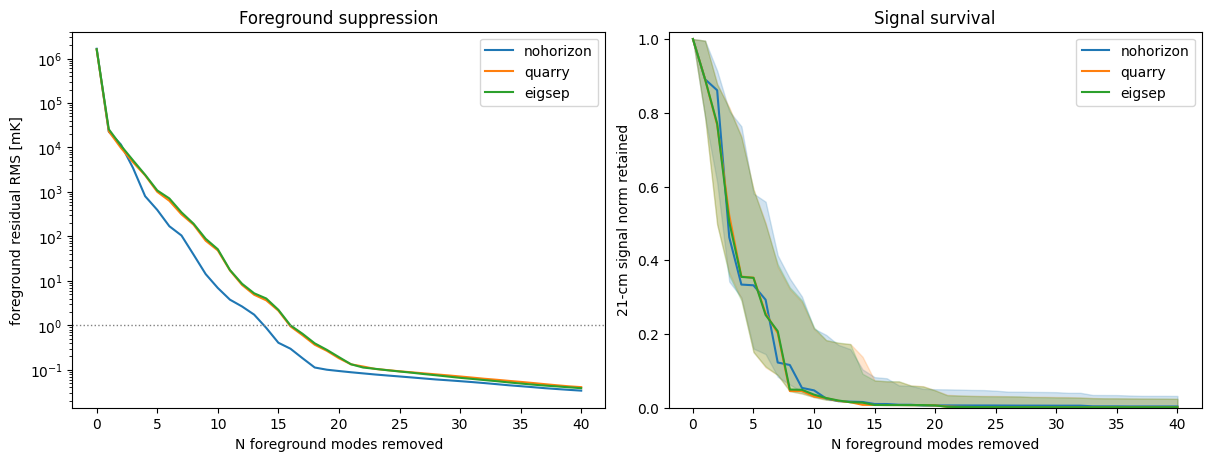

In [12]:
N_MAX = 40
n_modes = np.arange(N_MAX + 1)

fig, axs = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

norms_all = np.linalg.norm(t21, axis=1)
norm_nom = np.linalg.norm(t21_nom)
summary = {}

for c in CASES:
    s, V = svd[c]["s"], svd[c]["V"]
    n_total = extract[c]["n_samples"] * len(freqs)

    tail_power = np.concatenate([np.cumsum((s**2)[::-1])[::-1], [0.0]])
    fg_rms = np.sqrt(tail_power[n_modes] / n_total)  # [K]

    surv_nom = np.empty(len(n_modes))
    surv_lo = np.empty(len(n_modes))
    surv_hi = np.empty(len(n_modes))
    for N in n_modes:
        VN = V[:, :N]
        r_nom = t21_nom - VN @ (VN.T @ t21_nom)
        r_all = t21 - (t21 @ VN) @ VN.T
        surv_nom[N] = np.linalg.norm(r_nom) / norm_nom
        frac = np.linalg.norm(r_all, axis=1) / norms_all
        surv_lo[N], surv_hi[N] = np.percentile(frac, [16, 84])

    axs[0].semilogy(n_modes, fg_rms * 1e3, color=COLORS[c], label=c)
    axs[1].plot(n_modes, surv_nom, color=COLORS[c], label=c)
    axs[1].fill_between(n_modes, surv_lo, surv_hi, color=COLORS[c], alpha=0.2)
    summary[c] = dict(fg_rms=fg_rms, surv_nom=surv_nom)

axs[0].axhline(1.0, color="0.5", ls=":", lw=1)  # 1 mK reference
axs[0].set_xlabel("N foreground modes removed")
axs[0].set_ylabel("foreground residual RMS [mK]")
axs[0].set_title("Foreground suppression")
axs[0].legend()

axs[1].set_xlabel("N foreground modes removed")
axs[1].set_ylabel("21-cm signal norm retained")
axs[1].set_ylim(0, 1.02)
axs[1].set_title("Signal survival")
axs[1].legend()
plt.show()

fig.savefig("fig2_filtering.pdf", bbox_inches="tight")

In [13]:
# Killer numbers: modes needed to push foregrounds below 1 mK RMS,
# and the 21-cm signal surviving at that point.
print(f"{'case':12s} {'N (fg < 1 mK)':>14s} {'signal retained':>16s}")
for c in CASES:
    fg_rms, surv = summary[c]["fg_rms"], summary[c]["surv_nom"]
    below = np.nonzero(fg_rms * 1e3 < 1.0)[0]
    if below.size:
        N = int(below[0])
        print(f"{c:12s} {N:14d} {surv[N]:15.1%}")
    else:
        print(f"{c:12s} {'> ' + str(N_MAX):>14s} {'-':>16s}")

case          N (fg < 1 mK)  signal retained
nohorizon                14            1.6%
quarry                   16            0.7%
eigsep                   16            0.7%
